In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn import linear_model
from collections import OrderedDict

from sympy.physics.quantum.gate import normalized
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.metrics.pairwise import pairwise_distances
from scipy import stats
from tqdm import tqdm

In [2]:
NUM_SEEDS = 2
FEATURES = ('linear','xor_xor_xor')

LAYERS = [32,256,128,64,64,2]
TRAIN_DATASET_SIZE = 32768
TEST_DATASET_SIZE = 1024

BATCH_SIZE = 512

OP_FNS = {'and': np.logical_and, 'or': np.logical_or, 'xor': np.logical_xor}

# Data

In [3]:
def make_dataset(features=FEATURES, input_unit_size=16, num_samples=126, seed=123):
    np.random.seed(seed)

    inputs = np.random.binomial(1, 0.5, size=(num_samples, len(features)*input_unit_size))
    outputs = []

    for feature_i, feature_type in enumerate(features):
        input_unit = inputs[:, feature_i*input_unit_size:(feature_i+1)*input_unit_size]

        if feature_type == 'linear':
            input_unit[:, :4] =  input_unit[:, :1]
            output_unit = input_unit[:, :1]
        else:
            output_unit = np.zeros_like(input_unit[:, :1])
            def feature_val(input):
                top, left, right = [OP_FNS[op] for op in feature_type.split('_')]
                return top(left(input[0], input[1]), right(input[2], input[3]))

            for number, index in enumerate(np.random.permutation(num_samples)):
                while feature_val(input_unit[index]) != number % 2:
                    input_unit[index] = np.random.binomial(1,0.5, input_unit_size)
                output_unit[index] = feature_val(input_unit[index])

        outputs.append(output_unit)
    return {'inputs': inputs, 'labels': np.concatenate(outputs, axis=1)}


In [4]:
class Data(Dataset):
    def __init__(self, inputs, labels,device):
        self.data = torch.tensor(inputs,device=device,dtype=torch.float)
        self.target = torch.tensor(labels,device=device,dtype=torch.float)

    def __getitem__(self, index):
        x = self.data[index]
        y = self.target[index]

        return x,y

    def __len__(self):
        return len(self.data)

# Model

In [5]:
class MLP(nn.Module):
    def __init__(self, layer_sizes: list[int]):
        super(MLP, self).__init__()
        self.layer_sizes = layer_sizes
        layers = []
        for i in range(len(layer_sizes)-2):
            layer = nn.Linear(layer_sizes[i],layer_sizes[i+1])
            std = np.sqrt(2/(layer_sizes[i]+layer_sizes[i+1]))
            torch.nn.init.trunc_normal_(layer.weight,std=std,a=-2*std,b=2*std)
            layers.append((f'linear_{i}',layer))
            layers.append((f'leaky_relu_{i}',nn.LeakyReLU()))
        self.model_body = nn.Sequential(OrderedDict(layers))
        self.output = nn.Linear(layer_sizes[-2], layer_sizes[-1])
        std = np.sqrt(2/(layer_sizes[-2]+layer_sizes[-1]))
        torch.nn.init.trunc_normal_(self.output.weight,std=std,a=-2*std,b=2*std)

    def forward(self, x):
        x = self.model_body(x)
        out = self.output(x)
        return out, x


# Analysis

In [6]:
def analyze_rep_var_explained(fit_reps, fit_labels, test_reps, test_labels):
    scores = []
    total_var = torch.sum(torch.var(test_reps,dim=0))

    for feat in range(fit_labels.shape[-1]):
        reg = linear_model.LinearRegression()
        reg.fit(fit_labels[:, feat:feat+1], fit_reps)
        scores.append(reg.score(test_labels[:, feat:feat+1], test_reps))

    return scores, total_var

In [7]:
def accuracy(y,labels):
    accuracy = []
    for i in range(len(y[0])):
        accuracy.append(((y[:, i] > 0) == labels[:, i]).float().mean())
    return [((y > 0) == labels).float().mean()]+accuracy

# Training

In [8]:
def run(data_features=FEATURES, train_features=None, pretrain=None, units_per_feature=16, max_epochs=50000, train_size=TRAIN_DATASET_SIZE,batch_size=BATCH_SIZE,seeds=1, device='cpu', filename='results', epsilon=0, verbose=0,record_variance=False):
    device_ = torch.device(device)
    out_features = len(train_features) if train_features else len(data_features)
    model_layers = [units_per_feature*len(data_features), 256, 128, 64, 64, out_features]

    #output file setup
    file = open(f'results/{filename}.csv',mode='w')
    features = range(len(data_features)) if train_features is None else [train_features]
    v_file = open(f'results/variances/{filename}_variances.csv',mode='w')
    variance_labels = ['seed','total-variance']+[f'feature{i}-{data_features[i]}' for i in features]
    v_format = ','.join(['%d']+['%.8f']*(len(variance_labels)-1))+'\n'
    v_file.write(','.join(variance_labels)+'\n')
    data_labels = ['seed', 'epoch', 'test-loss','total-acc'] + ['%s_feature%i-%s' % (stat, i, str(data_features[i])) for stat in ('test-acc', 'test-loss') for i in features]
    out_format = ','.join(['%d', '%d'] + ['%.8f'] * (len(data_labels) - 2))+'\n'
    file.write(','.join(data_labels)+'\n')

    models = []
    for seed in range(seeds):
        torch.manual_seed(123 + seed)
        rng = np.random.default_rng(123 + seed)

        train_data = make_dataset(features=data_features, num_samples=train_size, input_unit_size=units_per_feature, seed=123+seed)
        val_data = make_dataset(features=data_features, num_samples=TEST_DATASET_SIZE, input_unit_size=units_per_feature, seed=1234+seed)
        test_data = make_dataset(features=data_features, num_samples=TEST_DATASET_SIZE, input_unit_size=units_per_feature, seed=12345+seed)

        if train_features:
            train_data['labels'] = train_data['labels'][:, train_features]
            val_data['labels'] = val_data['labels'][:, train_features]
            test_data['labels'] = test_data['labels'][:, train_features]

        train_loader = DataLoader(Data(train_data['inputs'], train_data['labels'], device), batch_size=batch_size, shuffle=True)
        x_val = torch.tensor(val_data['inputs'],device=device, dtype=torch.float)
        #y_val = torch.tensor(val_data['labels'],device=device, dtype=torch.float)
        x_test = torch.tensor(test_data['inputs'],device=device, dtype=torch.float)
        y_test = torch.tensor(test_data['labels'],device=device, dtype=torch.float)

        model = MLP(layer_sizes=model_layers).to(device_)
        criterion = nn.BCEWithLogitsLoss(reduction='mean')
        optimizer = optim.SGD(model.parameters())

        if pretrain:
            current_feature = pretrain[0]
            feature_number = 1

        vars_ = torch.Tensor()
        for epoch in tqdm(range(max_epochs)):
            model.train()
            for inputs, labels in train_loader:
                optimizer.zero_grad()
                outputs,_ = model(inputs)
                if pretrain:
                    outputs=outputs[:,current_feature]
                    labels=labels[:,current_feature]
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            if (epoch%500 == 0) or (epoch == max_epochs-1):
                with torch.no_grad():
                    model.eval()
                    y_pred, test_reps = model(x_test)
                    test_loss= criterion(y_pred, y_test)
                    test_accuracies = accuracy(y_pred,y_test)
                    test_feature_losses = [criterion(y_pred[:,i], y_test[:,i]) for i in range(len(y_pred[0]))]

                    if record_variance:
                        vp, val_reps = model(x_val)
                        reps = torch.stack([val_reps,test_reps],dim=0)
                        vars_ = torch.cat([vars_,reps])

                    outputs= (seed, epoch, test_loss, *test_accuracies, *test_feature_losses)
                    file.write(out_format % outputs)
                    if pretrain:
                        test_loss = criterion(y_pred[:,current_feature],y_test[:,current_feature])

                    if test_loss < epsilon:
                        if pretrain and feature_number < len(pretrain):
                            current_feature = pretrain[feature_number]
                            feature_number+=1
                            print(f'switching to feature {current_feature} at epoch {epoch}')
                        else:
                            print(f'stopping early at epoch {epoch}')
                            break
        if record_variance:
            for i in range(0,len(vars),2):
                variance_scores, total_variance = analyze_rep_var_explained(vars_[i].cpu(), val_data['labels'], vars_[i+1].cpu(), test_data['labels'])
                v_out = (seed,total_variance,*variance_scores)
                v_file.write(v_format % v_out)

        models.append(model)
        path =f'models/{filename}-{seed}.pt'
        torch.save(model.state_dict(),path)
        print(f'seed {seed} acc: {test_accuracies[0]}, loss: {test_loss}')

    return models

# Networks

In [9]:
models = {}

In [ ]:
run_name = 'multitask'
print(run_name)
models[run_name] =run(data_features=['linear','xor_xor_xor'],seeds=10,max_epochs=20000,epsilon=1e-3,filename=run_name,device='cpu',record_variance=True)

multitask


  4%|▍         | 848/20000 [02:33<57:26,  5.56it/s]  

In [70]:
run_name = 'pretrain_easy'
print(run_name)
models[run_name] =run(data_features=['linear','xor_xor_xor'],seeds=10,max_epochs=20000,epsilon=1e-3,filename=run_name,device='cpu',record_variance=True,pretrain=[0,1])

run_name = 'pretrain_hard'
print(run_name)
models[run_name] =run(data_features=['linear','xor_xor_xor'],seeds=10,max_epochs=20000,epsilon=1e-3,filename=run_name,device='cpu',record_variance=True,pretrain=[1,0])

 25%|██▌       | 502/2000 [01:24<04:07,  6.05it/s]

switching to feature 0 at epoch 500


 50%|█████     | 1000/2000 [02:48<02:48,  5.93it/s]

stopping early at epoch 1000
seed 0 acc: 0.99951171875, loss: 0.0004585531132761389


In [ ]:
run_name = 'easy'
print(run_name)
models[run_name] =run(data_features=['linear','xor_xor_xor'],seeds=5,max_epochs=20000,epsilon=1e-3,filename=run_name,device='cpu',train_features=[0])

run_name = 'hard'
print(run_name)
models[run_name] =run(data_features=['linear','xor_xor_xor'],seeds=5,max_epochs=20000,epsilon=1e-3,filename=run_name,device='cpu',train_features=[1])

run_name = 'multiple_easy'
print(run_name)
models[run_name] =run(data_features=['linear','linear'],seeds=5,max_epochs=20000,epsilon=1e-3,filename=run_name,device='cpu')

run_name = 'multiple_hard'
print(run_name)
models[run_name] =run(data_features=['xor_xor_xor','xor_xor_xor'],seeds=5,max_epochs=20000,epsilon=1e-3,filename=run_name,device='cpu')


In [71]:
run_name='multitask'
results = pd.read_csv(f'results/{run_name}.csv')
variances = pd.read_csv(f'results/{run_name}_variances.csv')

In [ ]:

tot = variances['total-variance'].iloc[-1]
variances['easy_norm'] = variances['feature0-linear']/tot
variances['hard_norm'] = variances['feature1-xor_xor_xor']/tot
normalized = variances.loc[:,['easy_norm','hard_norm']]
#variances['epoch'] = results['epoch']
'''df = pd.DataFrame(accuracies,columns=['easy','hard'])
df['epoch'] = df.index*500
df = df.melt('epoch', var_name='task', value_name='accuracy')
df['accuracy'] = df['accuracy'].infer_objects()
df2 = pd.DataFrame(representations, columns=['easy', 'hard'])
df2['epoch'] = df2.index*500
df2 =df2.melt('epoch',var_name='task',value_name='variance')'''

fig, ax = plt.subplots(ncols=3, figsize=(12,4))
sns.lineplot(data=results,x='epoch',y="test-acc_feature0-linear",ax=ax[0])
sns.lineplot(data=results,x='epoch',y="test-acc_feature1-xor_xor_xor",ax=ax[0])
#sns.lineplot(data=variances,x='epoch',y='easy',ax=axs[1])
#sns.lineplot(data=variances,x='epoch',y='hard',ax=axs[1])
sns.lineplot(data=normalized,ax=ax[1])
sns.lineplot(data=results,x='epoch',y='test-loss_feature0-linear',ax=ax[2])
sns.lineplot(data=results,x='epoch',y='test-loss_feature1-xor_xor_xor',ax=ax[2])
ax[0].set_ylim(-0.1,1.1)
ax[1].set_ylim(-0.1,1.1)
ax[2].set_ylim(-0.1,1.1)
plt.show()

# RSA

In [345]:
def rsa(inputs, model1, model2):
    model1.eval()
    y1, reps1 = model1(inputs)
    model2.eval()
    y2, reps2 = model2(inputs)
    reps1 = reps1.cpu().detach().numpy()
    reps2 = reps2.cpu().detach().numpy()

    rdm1 = pairwise_distances(reps1,metric='euclidean')
    rdm2 = pairwise_distances(reps2,metric='euclidean')

    similarity = stats.pearsonr(np.triu(rdm1),np.triu(rdm2),axis=None)

    return similarity.correlation


In [343]:
data = make_dataset(features=['and_and_and','and_and_and'], num_samples=TEST_DATASET_SIZE, input_unit_size=16, seed=12345)
stimuli = torch.tensor(data['inputs'],device=torch.device('cpu'),dtype=torch.float)
similarities = {}

for i, a in models.items():
    similarities[i] = {}
    for j, b in models.items():
        similarities[i][j] = rsa(stimuli, a[0], b[1])

In [ ]:
df = pd.DataFrame(similarities)
plt1 = df.loc[['hard','multitask','easy'],['easy','multitask','hard']]
plt2 = df.loc[['multiple hard','multiple easy'],['multiple easy','multiple hard']]

c = sns.color_palette("blend:#FFD,#005",as_cmap=True)#.reversed()
fig, axs = plt.subplots(ncols=2, figsize=(10,4))
sns.heatmap(plt1,cmap=c,vmax=1,vmin=0,ax=axs[0])
sns.heatmap(plt2,vmax=1,cmap=c,vmin=0,ax=axs[1])

# PCA

In [282]:
def to_pcs(fit_activations, fit_labels, test_activations, test_labels,n=2):
    X = fit_activations
    X_std = (X-np.mean(X))/np.std(X)
    pca_ = PCA(n_components=n)
    pca_.fit(X_std)
    X1 = test_activations
    X_test = (X1-np.mean(X1))/np.std(X1)
    fit_pcs = pca_.transform(X_std)
    test_pcs = pca_.transform(X_test)
    y_fit = (fit_labels[:,:]>0).astype(int)
    y_test = (test_labels[:,:]>0).astype(int)
    return fit_pcs,y_fit,test_pcs,y_test


In [312]:
def pca(model, n=2):
    data = make_dataset(features=['linear', 'xor_xor_xor'], num_samples=2*TEST_DATASET_SIZE, input_unit_size=16, seed=1234)
    x = torch.tensor(data['inputs'],device='cpu',dtype=torch.float)
    model.eval()
    outputs,activations = model(x)
    fit_pcs,fit_labels,test_pcs,test_labels = to_pcs(activations[:TEST_DATASET_SIZE].detach().numpy(),data['labels'][:TEST_DATASET_SIZE],activations[TEST_DATASET_SIZE:].detach().numpy(),data['labels'][TEST_DATASET_SIZE:], n=n)

    pc_scs, pc_tot = analyze_rep_var_explained(fit_pcs,data['labels'][:TEST_DATASET_SIZE],test_pcs,data['labels'][TEST_DATASET_SIZE:])
    scs, tot = analyze_rep_var_explained(activations[:TEST_DATASET_SIZE].detach().numpy(),data['labels'][:TEST_DATASET_SIZE],activations[TEST_DATASET_SIZE:].detach().numpy(),data['labels'][TEST_DATASET_SIZE:])

    train = pd.DataFrame(np.concatenate([fit_pcs,fit_labels],axis=1),columns=[i+1 for i in range(n)]+['easy','hard'])
    test = pd.DataFrame(np.concatenate([test_pcs,test_labels],axis=1),columns=[i+1 for i in range(n)]+['easy','hard'])
    return train, test,(pc_scs,pc_tot,scs,tot)

In [337]:
model = MLP(layer_sizes=[32, 256, 128, 64, 64, 2])
model.load_state_dict(torch.load('models/multiseed-0.pt'))

pcs=pca(model,n=6)
print(f'activation variance:\neasy: {pcs[2][2][0]}   hard: {pcs[2][2][1]}\nprincipal component variance:\neasy: {pcs[2][0][0]}   hard: {pcs[2][0][1]}')

activation variance:
easy: 0.7234204460366305   hard: 0.0022181058002106093
principal component variance:
easy: 0.15898948332968654   hard: 0.16296488805510181


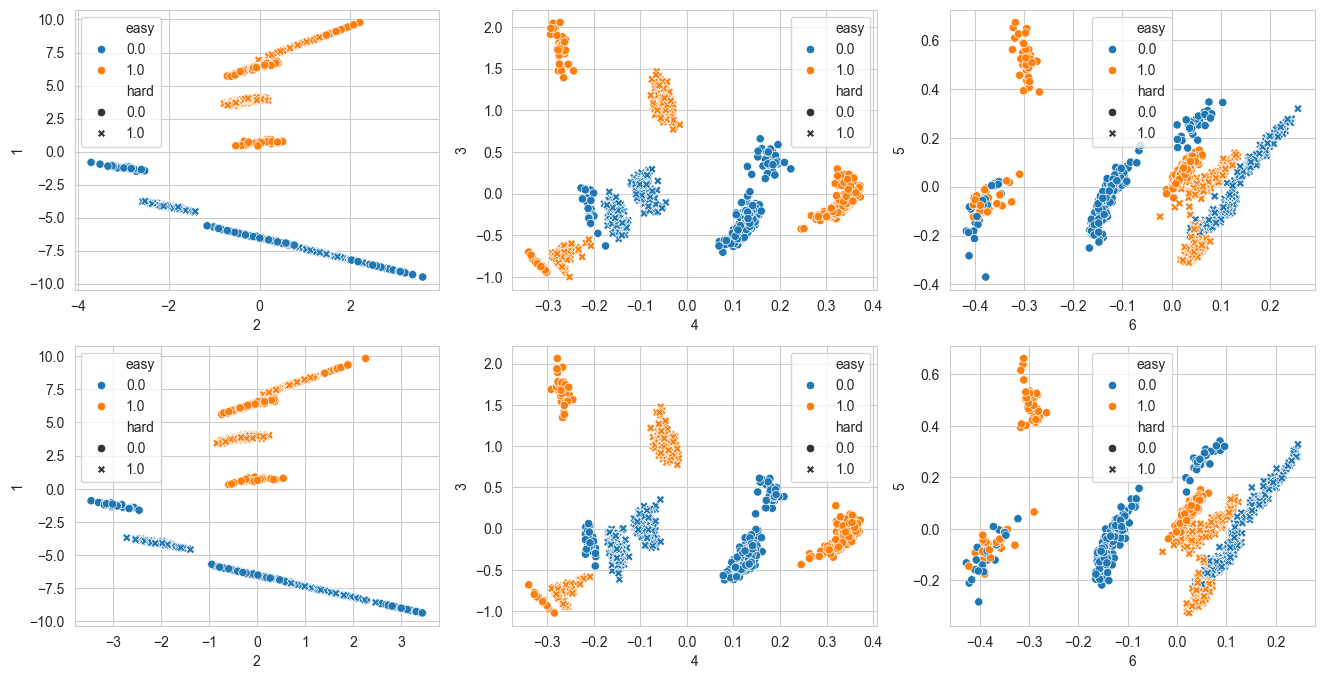

In [338]:
fig, axs = plt.subplots(ncols=3,nrows=2, figsize=(16,8))
sns.scatterplot(data=pcs[0],x=2,y=1,hue='easy',style='hard',ax=axs[0,0])
sns.scatterplot(data=pcs[0],x=4,y=3,hue='easy',style='hard',ax=axs[0,1])
sns.scatterplot(data=pcs[0],x=6,y=5,hue='easy',style='hard',ax=axs[0,2])
sns.scatterplot(data=pcs[1],x=2,y=1,hue='easy',style='hard',ax=axs[1,0])
sns.scatterplot(data=pcs[1],x=4,y=3,hue='easy',style='hard',ax=axs[1,1])
sns.scatterplot(data=pcs[1],x=6,y=5,hue='easy',style='hard',ax=axs[1,2])
plt.show()

# Neural Predictivity (WIP)

In [346]:
def score(activation1, activation2,activations1_test,activation2_test):
    regr = linear_model.LinearRegression()
    regr.fit(activation1, activation2)
    pred = regr.predict(activations1_test)
    corr_score = stats.pearsonr(pred,activation2_test,axis=None)
    reg_score = regr.score(activations1_test, activation2_test)
    return corr_score, reg_score

In [76]:
data = make_dataset(features=['linear','xor_xor_xor'], num_samples=TEST_DATASET_SIZE, input_unit_size=16, seed=12345)
x1 = torch.tensor(data['inputs'],device=torch.device('mps'),dtype=torch.float)
data2 = make_dataset(features=['linear','xor_xor_xor'], num_samples=TEST_DATASET_SIZE, input_unit_size=16, seed=1234)
x2 = torch.tensor(data2['inputs'],device=torch.device('mps'),dtype=torch.float)

In [174]:
fitx = models['multitask'][0](x1)[1].cpu().detach()
testx =models['multitask'][0](x2)[1].cpu().detach()

fity = models['easy'][1](x1)[1].cpu().detach()
testy =models['easy'][1](x2)[1].cpu().detach()

In [226]:
preds = {}

for i, a in models.items():
    preds[i] = {}
    for j, b in models.items():
        fitx = a[0](x1)[1].cpu().detach()
        testx =a[0](x2)[1].cpu().detach()

        fity = b[1](x1)[1].cpu().detach()
        testy = b[1](x2)[1].cpu().detach()
        _,preds[i][j] = score(fitx,fity,testx,testy)

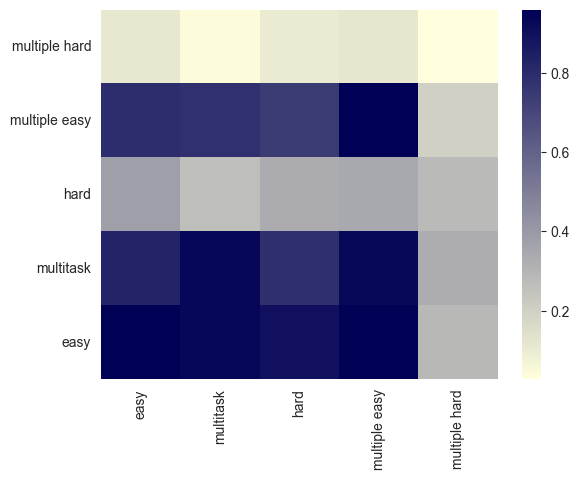

In [231]:
df = pd.DataFrame(preds)


c = sns.color_palette("blend:#FFD,#005",as_cmap=True)#.reversed()
#fig, axs = plt.subplots(ncols=2, figsize=(10,4))

ax = sns.heatmap(df,cmap=c)
ax.invert_yaxis()
plt.show()

In [228]:
predspc = {}

for i, a in models.items():
    predspc[i] = {}
    for j, b in models.items():
        p, at = a[0](x1)
        p2,at2 =a[0](x2)
        fitx,_,testx,_ = to_pcs(at.cpu().detach().numpy(),p.cpu().detach().numpy(),at2.cpu().detach().numpy(),p2.cpu().detach().numpy(),n=6)


        fity = b[1](x1)[1].cpu().detach()
        testy = b[1](x2)[1].cpu().detach()
        _,predspc[i][j] = score(fitx,fity,testx,testy)

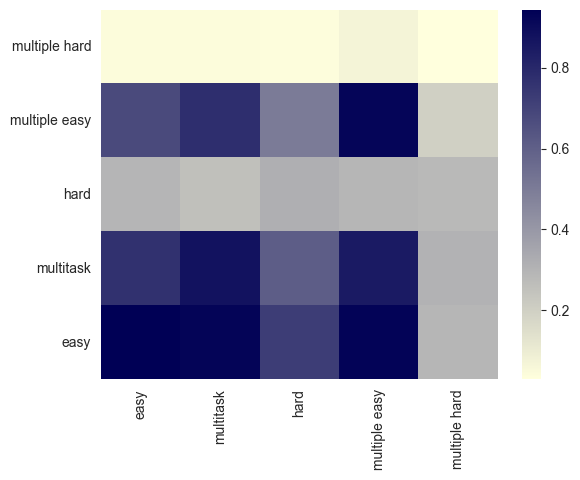

In [230]:
df2 = pd.DataFrame(predspc)


c = sns.color_palette("blend:#FFD,#005",as_cmap=True)#.reversed()
#fig, axs = plt.subplots(ncols=2, figsize=(10,4))

ax = sns.heatmap(df2,cmap=c)
ax.invert_yaxis()
plt.show()